In [1]:
# Carregando bibliotecas

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
# --- 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS ---

def carregar_mnist_bipolar(numeros_desejados=[0, 1, 5, 9]):
    print("Baixando MNIST... (isso pode demorar um pouco na primeira vez)")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist.data, mnist.target.astype(int)

    padroes_treino = []

    for num in numeros_desejados:
        # Pega a primeira ocorrência de cada número desejado
        idx = np.where(y == num)[0][0]
        # Converte para bipolar: pixels > 127 viram 1, o resto vira -1
        img_bipolar = np.where(X[idx] > 127, 1, -1)
        padroes_treino.append(img_bipolar)

    return np.array(padroes_treino)

In [3]:
# --- 2. FUNÇÕES DA REDE DE HOPFIELD ---

def treinar_hopfield(padroes):
    """
    Regra de Hebb: W = (1/N) * sum(p * p.T)
    """
    n_padroes, n_nos = padroes.shape
    W = np.zeros((n_nos, n_nos))

    for p in padroes:
        W += np.outer(p, p)

    W = W / n_nos
    np.fill_diagonal(W, 0) # Garante que não haja auto-feedback
    return W

def calcular_energia(x, W):
    """Calcula a energia da rede para o estado atual x"""
    return -0.5 * np.dot(x.T, np.dot(W, x))

def recuperar_padrao_com_energia(y_inicial, W, maxit=20000):
    n_nos = len(y_inicial)
    y = y_inicial.copy().astype(float)
    converge = False
    ordem = np.arange(n_nos)

    # Lista para guardar a energia ao longo do tempo
    historico_energia = []

    for it in range(maxit):
        # Registra a energia no início de cada iteração (ou a cada N iterações)
        # Para o MNIST, registrar a cada pixel pode ser lento,
        # então registramos a cada 10 pixels ou a cada época.
        if it % 10 == 0:
            historico_energia.append(calcular_energia(y, W))

        if it % n_nos == 0:
            if it > 0 and converge:
                print(f"Alcançou estado estável na iteração {it}")
                break
            ordem = np.random.permutation(n_nos)
            converge = True

        i = ordem[it % n_nos]
        yi_old = y[i]

        v = np.dot(W[i, :], y)

        if v > 0:
            y[i] = 1
        elif v < 0:
            y[i] = -1

        if yi_old != y[i]:
            converge = False

    return y, historico_energia

In [4]:
# --- 3. FUNÇÃO DE RUÍDO (A que causa a inversão) ---

def adicionar_ruido_bipolar(imagem, percentual=0.1):
    """
    Troca 1 por -1 e vice-versa baseado num percentual.
    Se percentual > 0.5, a rede tende a convergir para o inverso!
    """
    resultado = imagem.copy()
    n_pixels = len(imagem)
    indices = np.random.choice(n_pixels, int(n_pixels * percentual), replace=False)
    resultado[indices] *= -1 # Inverte o sinal
    return resultado

In [5]:
# --- 4. EXECUÇÃO DO EXPERIMENTO ---

# 1. Preparar dados
padroes = carregar_mnist_bipolar([0, 1, 5, 9])
W = treinar_hopfield(padroes)

# 2. Criar teste com ruído. Se colocar muito (por exemplo 60%), da pra ver a inversão
img_original = padroes[0]
img_ruidosa = adicionar_ruido_bipolar(img_original, percentual=0.1)

# 3. Recuperar (maxit deve ser grande para cobrir 784 neurônios várias vezes)
img_recuperada, energias = recuperar_padrao_com_energia(img_ruidosa, W, maxit=784*20)

Baixando MNIST... (isso pode demorar um pouco na primeira vez)
Alcançou estado estável na iteração 1568


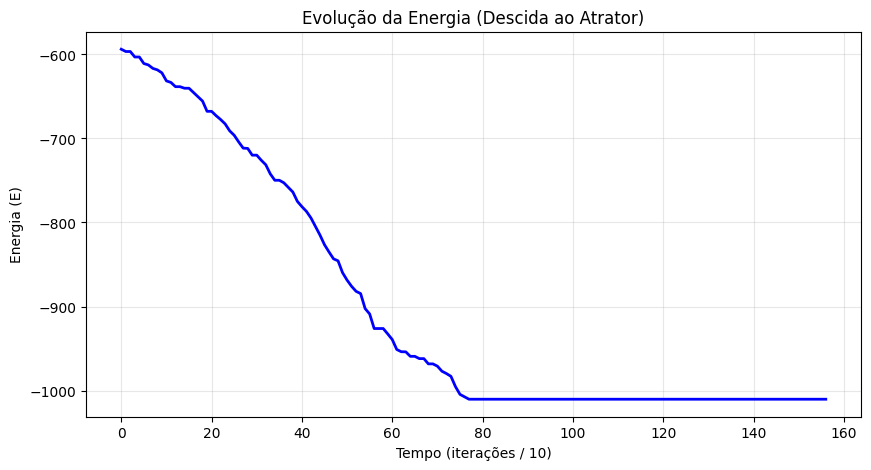

In [6]:
# 4. Plotar o comportamento da Energia
plt.figure(figsize=(10, 5))
plt.plot(energias, color='blue', linewidth=2)
plt.title("Evolução da Energia (Descida ao Atrator)")
plt.xlabel("Tempo (iterações / 10)")
plt.ylabel("Energia (E)")
plt.grid(True, alpha=0.3)
plt.show()

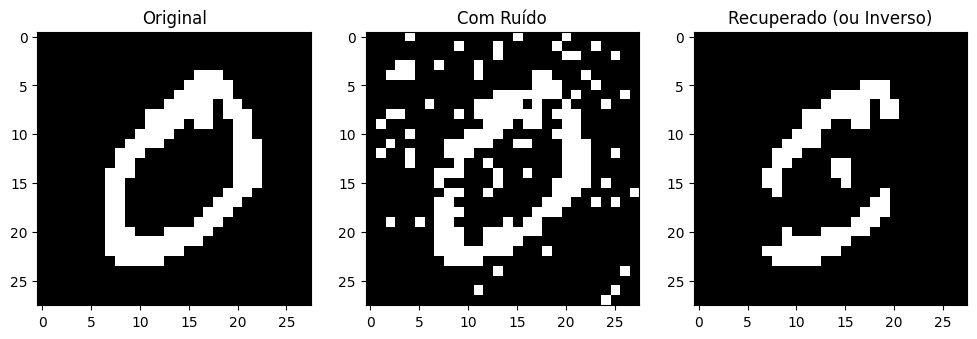

In [7]:
# 5. Visualização
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_original.reshape(28, 28), cmap='gray')
ax[0].set_title("Original")
ax[1].imshow(img_ruidosa.reshape(28, 28), cmap='gray')
ax[1].set_title("Com Ruído")
ax[2].imshow(img_recuperada.reshape(28, 28), cmap='gray')
ax[2].set_title("Recuperado (ou Inverso)")
plt.show()

Alcançou estado estável na iteração 1568


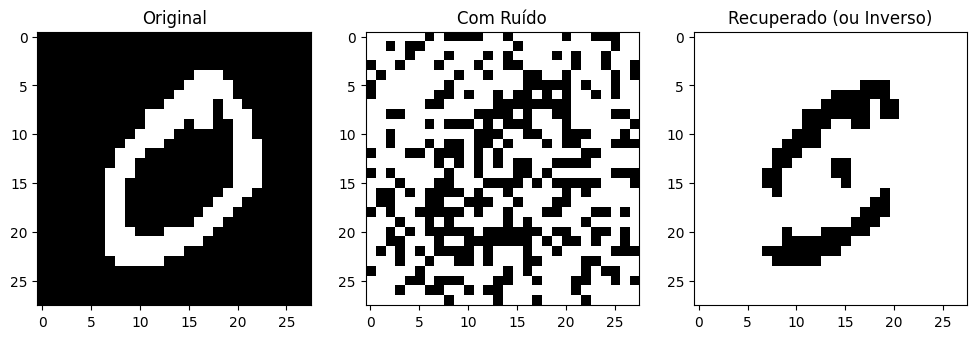

In [8]:
# 6. Visualização com muito ruido

# Criar teste com ruído. Se colocar muito (por exemplo 60%), da pra ver a inversão
img_original = padroes[0]
img_ruidosa = adicionar_ruido_bipolar(img_original, percentual=0.7)

# Recuperar (maxit deve ser grande para cobrir 784 neurônios várias vezes)
img_recuperada, energias = recuperar_padrao_com_energia(img_ruidosa, W, maxit=784*20)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_original.reshape(28, 28), cmap='gray')
ax[0].set_title("Original")
ax[1].imshow(img_ruidosa.reshape(28, 28), cmap='gray')
ax[1].set_title("Com Ruído")
ax[2].imshow(img_recuperada.reshape(28, 28), cmap='gray')
ax[2].set_title("Recuperado (ou Inverso)")
plt.show()

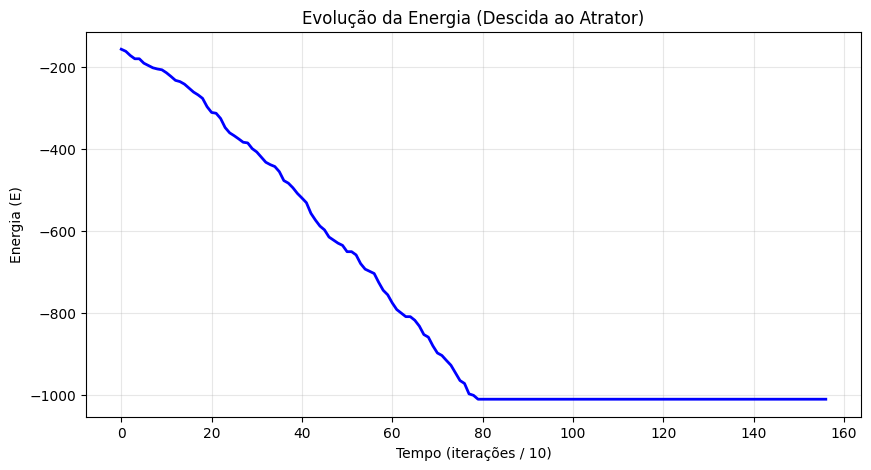

In [9]:
# 4. Plotar o comportamento da Energia
plt.figure(figsize=(10, 5))
plt.plot(energias, color='blue', linewidth=2)
plt.title("Evolução da Energia (Descida ao Atrator)")
plt.xlabel("Tempo (iterações / 10)")
plt.ylabel("Energia (E)")
plt.grid(True, alpha=0.3)
plt.show()